Dataset Size: 25000
Label Distribution: Counter({1: 15116, 0: 9884})
Vocabulary Size: 9132
Epoch [1/100] Train Loss: 0.6928 | Val Loss: 0.6862 | Val Acc: 61.92%
Epoch [2/100] Train Loss: 0.6807 | Val Loss: 0.6749 | Val Acc: 61.00%
Epoch [3/100] Train Loss: 0.6690 | Val Loss: 0.6634 | Val Acc: 60.84%
Epoch [4/100] Train Loss: 0.6564 | Val Loss: 0.6512 | Val Acc: 60.84%
Epoch [5/100] Train Loss: 0.6424 | Val Loss: 0.6370 | Val Acc: 61.32%
Epoch [6/100] Train Loss: 0.6233 | Val Loss: 0.6173 | Val Acc: 63.04%
Epoch [7/100] Train Loss: 0.5975 | Val Loss: 0.5928 | Val Acc: 67.40%
Epoch [8/100] Train Loss: 0.5686 | Val Loss: 0.5663 | Val Acc: 71.56%
Epoch [9/100] Train Loss: 0.5408 | Val Loss: 0.5438 | Val Acc: 74.00%
Epoch [10/100] Train Loss: 0.5174 | Val Loss: 0.5259 | Val Acc: 75.76%
Epoch [11/100] Train Loss: 0.4984 | Val Loss: 0.5116 | Val Acc: 77.04%
Epoch [12/100] Train Loss: 0.4834 | Val Loss: 0.5000 | Val Acc: 78.28%
Epoch [13/100] Train Loss: 0.4708 | Val Loss: 0.4909 | Val Acc: 78

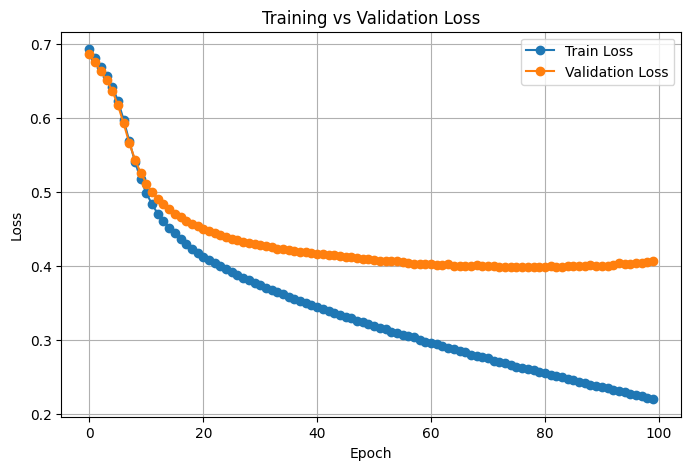


Test Accuracy: 85.12 %

Classification Report:

              precision    recall  f1-score   support

         0.0     0.8237    0.7937    0.8084       989
         1.0     0.8681    0.8888    0.8784      1511

    accuracy                         0.8512      2500
   macro avg     0.8459    0.8413    0.8434      2500
weighted avg     0.8506    0.8512    0.8507      2500


Confusion Matrix:

[[ 785  204]
 [ 168 1343]]


In [ ]:
# =========================
# 1. Imports
# =========================
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================
# 2. Reproducibility
# =========================
SEED = 42

np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# 3. Load Data
# =========================
data = pd.read_csv(
    "amazon_cells_labelled_LARGE_25K.txt",
    delimiter="\t",
    header=None
)

data.columns = ["Sentence", "Class"]

data["Sentence"] = data["Sentence"].astype(str).str.strip()

texts = data["Sentence"].tolist()
labels = data["Class"].tolist()

print("Dataset Size:", len(labels))
print("Label Distribution:", Counter(labels))

# =========================
# 4. Train / Val / Test Split
# =========================
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

# =========================
# 5. Text Cleaning
# =========================
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

MAX_VOCAB_SIZE = 20000
MIN_FREQ = 2
MAX_SEQ_LEN = 40


def clean_text(text):
    text = text.lower().strip()

    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


train_texts = [clean_text(t) for t in train_texts]
val_texts = [clean_text(t) for t in val_texts]
test_texts = [clean_text(t) for t in test_texts]

# =========================
# 6. Build Vocabulary
# =========================
def build_vocab(sentences, min_freq=2, max_size=20000):

    counter = Counter()

    for sentence in sentences:
        counter.update(sentence.split())

    vocab = {
        PAD_TOKEN: 0,
        UNK_TOKEN: 1
    }

    most_common = counter.most_common(max_size)

    idx = 2

    for token, freq in most_common:

        if freq >= min_freq:
            vocab[token] = idx
            idx += 1

    return vocab


vocab = build_vocab(train_texts)

pad_idx = vocab[PAD_TOKEN]
unk_idx = vocab[UNK_TOKEN]

vocab_size = len(vocab)

print("Vocabulary Size:", vocab_size)

# =========================
# 7. Encode Sentences
# =========================
def encode_sentence(sentence, vocab, max_len=40):

    tokens = sentence.split()

    token_ids = [
        vocab.get(token, unk_idx)
        for token in tokens[:max_len]
    ]

    length = len(token_ids)

    if length < max_len:
        token_ids += [pad_idx] * (max_len - length)

    return token_ids, length


# =========================
# 8. Dataset
# =========================
class TextDataset(Dataset):

    def __init__(self, texts, labels, vocab):

        self.inputs = []
        self.lengths = []

        for text in texts:

            encoded, length = encode_sentence(
                text,
                vocab,
                MAX_SEQ_LEN
            )

            self.inputs.append(torch.tensor(encoded))
            self.lengths.append(length)

        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return (
            self.inputs[idx],
            self.lengths[idx],
            self.labels[idx]
        )


# =========================
# 9. DataLoaders
# =========================
BATCH_SIZE = 64

train_loader = DataLoader(
    TextDataset(train_texts, train_labels, vocab),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TextDataset(val_texts, val_labels, vocab),
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    TextDataset(test_texts, test_labels, vocab),
    batch_size=BATCH_SIZE
)

# =========================
# 10. BiLSTM Model
# =========================
class simpleBiLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        hidden_dim=128,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x, lengths):

        embedded = self.embedding(x)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_output, _ = self.lstm(packed)

        output, _ = nn.utils.rnn.pad_packed_sequence(
            packed_output,
            batch_first=True
        )

        pooled = output.mean(dim=1)

        pooled = self.dropout(pooled)

        logits = self.fc(pooled)

        return logits.squeeze(1)


# =========================
# 11. Evaluation Function
# =========================
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    predictions = []
    true_labels = []

    with torch.no_grad():

        for x, lengths, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x, lengths)

            loss = criterion(outputs, y)

            total_loss += loss.item() * y.size(0)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    accuracy = (
        np.mean(np.array(predictions) == np.array(true_labels))
        * 100
    )

    return avg_loss, accuracy, predictions, true_labels


# =========================
# 12. Training Function
# =========================
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-5
):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-5
    )

    criterion = nn.BCEWithLogitsLoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()

        total_train_loss = 0

        for x, lengths, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            outputs = model(x, lengths)

            loss = criterion(outputs, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0
            )

            optimizer.step()

            total_train_loss += loss.item() * y.size(0)

        avg_train_loss = (
            total_train_loss / len(train_loader.dataset)
        )

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    return model, train_losses, val_losses


# =========================
# 13. Train Model
# =========================
model = simpleBiLSTM(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    dropout=0.3
)

model, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-5
)

# =========================
# 14. Plot Loss Curves
# =========================
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Train Loss",
    marker="o"
)

plt.plot(
    val_losses,
    label="Validation Loss",
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

# =========================
# 15. Final Test Evaluation
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

criterion = nn.BCEWithLogitsLoss()

test_loss, test_acc, preds, true_labels = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("\nTest Accuracy:", round(test_acc, 2), "%")

# =========================
# 16. Classification Report
# =========================
print("\nClassification Report:\n")

print(
    classification_report(
        true_labels,
        preds,
        digits=4
    )
)

print("\nConfusion Matrix:\n")

print(
    confusion_matrix(
        true_labels,
        preds
    )
)